In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from pathlib import Path
import scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import torch
import numpy as np
import cv2

PROJECT_ROOT = Path.cwd().parent

# 2. Target maps

## 2.1 Density-map

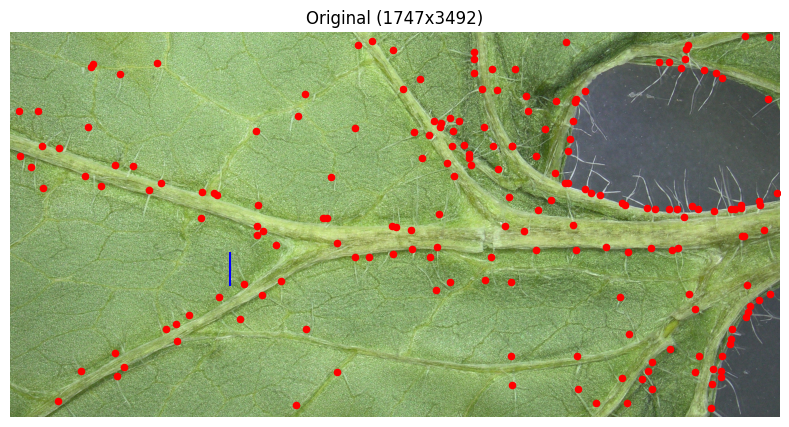

In [ ]:
# Find out rough typical trichome length
from trichomecounter.utils.utils import get_random_data_paths
from trichomecounter.utils.visualizations import plot_image

# Get image and coord paths
_, _, img_path, coord_path = get_random_data_paths()

# Load image and coordinates
img = cv2.imread(str(img_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
coords = np.load(coord_path)
H,W,_ = img.shape

# Plot image and visual orientation line
fig,ax = plt.subplots(figsize=(10,5))
plot_image(img, coords, title=f"Original ({H}x{W})",ax=ax)
trichome_length = 150 # in px -> Change until optically the vline matches a typical trichome length
ax.vlines(x=1000,ymin=1000,ymax=1000+trichome_length,colors="blue");

Trichome-lenght of 150 seems to roughly match typical trichome length.

=> ResizeShortSide(512) => Trichome-length *= 512/1747 => Trichome-length after resize around 40px

To create the density map we want to choose sigma s.t. the density is not to narrow around the noisy image coordinates but also not to wide.

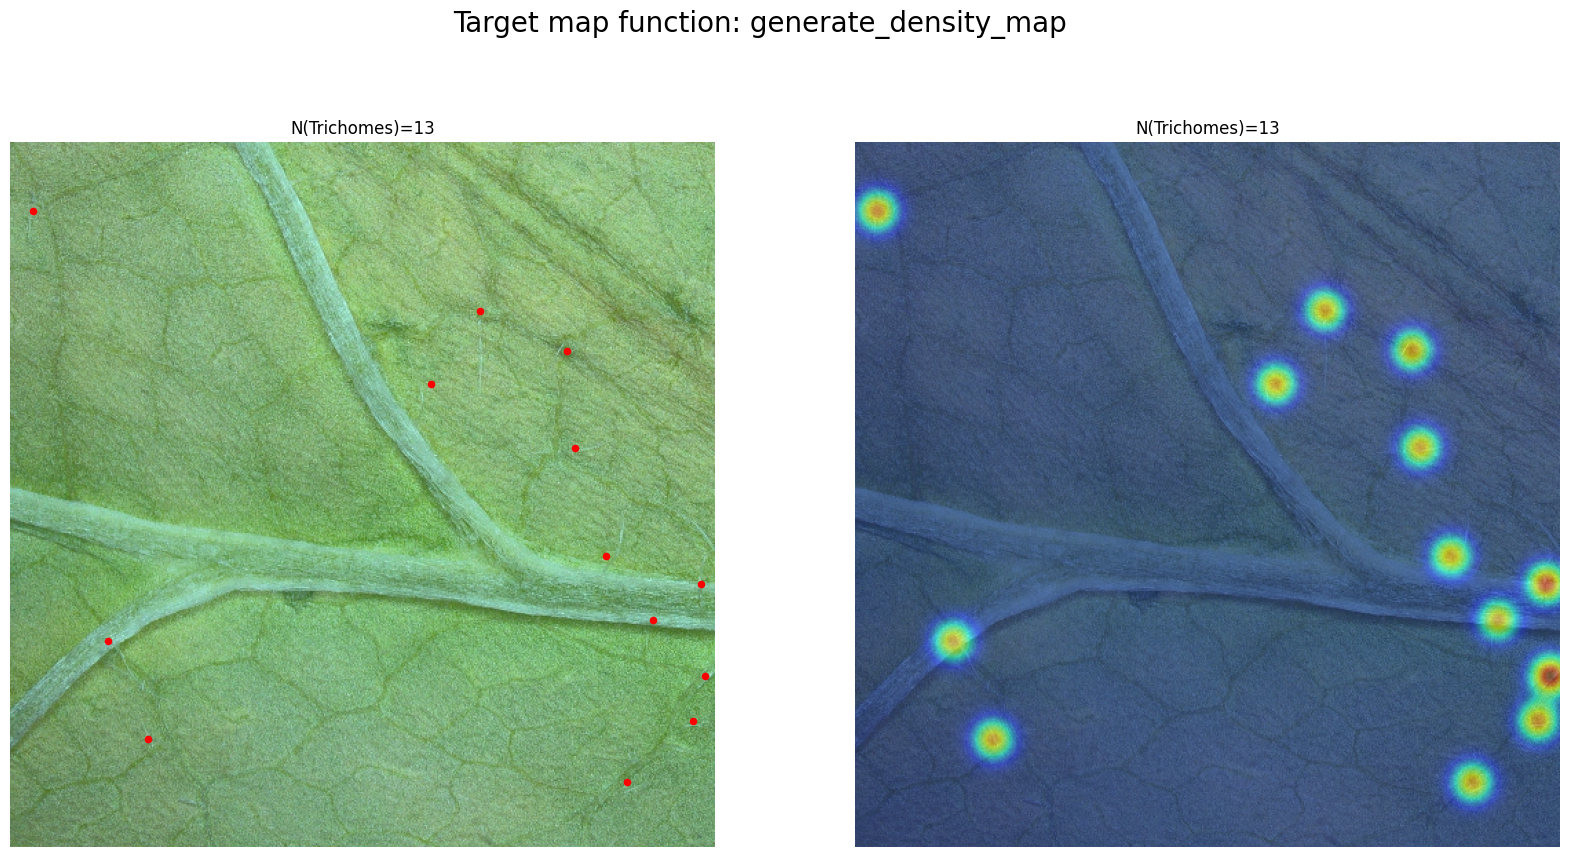

In [ ]:
# Sanity check: Inspect density map outcome
from trichomecounter.utils.utils import get_random_data_paths
from trichomecounter.data import data_transformations as transforms
from trichomecounter.model.target_maps import generate_density_map
from trichomecounter.utils.visualizations import plot_image, plot_density_map


# Get random image and coord paths
_, _, img_path, coord_path = get_random_data_paths()

# Load image and coordinates
img = cv2.imread(str(img_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
coords = np.load(coord_path)

# Get data into expected PyTorch data formats before transformation application
img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
coords = torch.from_numpy(coords).float()

# Resize for faster processing
resize = transforms.Compose([transforms.ResizeShortSide(512),transforms.RandomCrop(512,512)])
img, coords = resize(img, coords)

# Generate density map
_,H,W = img.shape
density_map = generate_density_map(coords, H, W, sigma=10)

# Get trichome counts
trichome_count_actual = len(coords)
trichome_count_density = round(density_map.sum().item()) # TODO: Decide across target map functions if density sum defines number of trichomes or local maxima

# Plot data instance and density map
fig, ax = plt.subplots(1,2,figsize=(20,10))
plt.suptitle("Target map function: generate_density_map", size=20)
plot_image(img, coords, title=f"N(Trichomes)={trichome_count_actual}", ax=ax[0])
plot_density_map(density_map, img, title=f"N(Trichomes)={trichome_count_density}", ax=ax[1]);

**Note**: At areas with high trichome density, density map naturally reflects that but separation of individual trichomes is not reflected at these areas. 

**Note 2**: Trichomes typically along leave veins => Danger of shortcut learning / getting stuck in local optimum, where leave veins are detected.